
BASE-10 RENORMALIZATION VISUALIZATION SUITE

Hypothesis: Physical quantities are bounded by the maximum
digit in the fundamental numerical representation of reality.
For base-10: maximum digit = 9 → natural cutoff at Λ = 9

[1/3] Standard vs. Base-10 Renormalization...
  ✓ Saved: base10_renormalization_comparison.png

[2/3] Black Hole with Base-10 Cutoff...
  ✓ Saved: black_hole_base10_core.png

[3/3] Numerical Base Dependence...
  ✓ Saved: base_dependence_cutoffs.png

VISUALIZATIONS COMPLETE!

📁 FILES GENERATED:
  • base10_renormalization_comparison.png
  • black_hole_base10_core.png
  • base_dependence_cutoffs.png

 KEY INSIGHTS:
  1. Standard renormalization: Λ→∞ (arbitrary, divergent)
  2. Base-10 renormalization: Λ=9 (structural, bounded)
  3. Black hole singularity: not infinite density, but saturated state
  4. The specific base may vary, but FINITUDE is invariant

Foundation for Paper #2: 'Base-10 Renormalization'


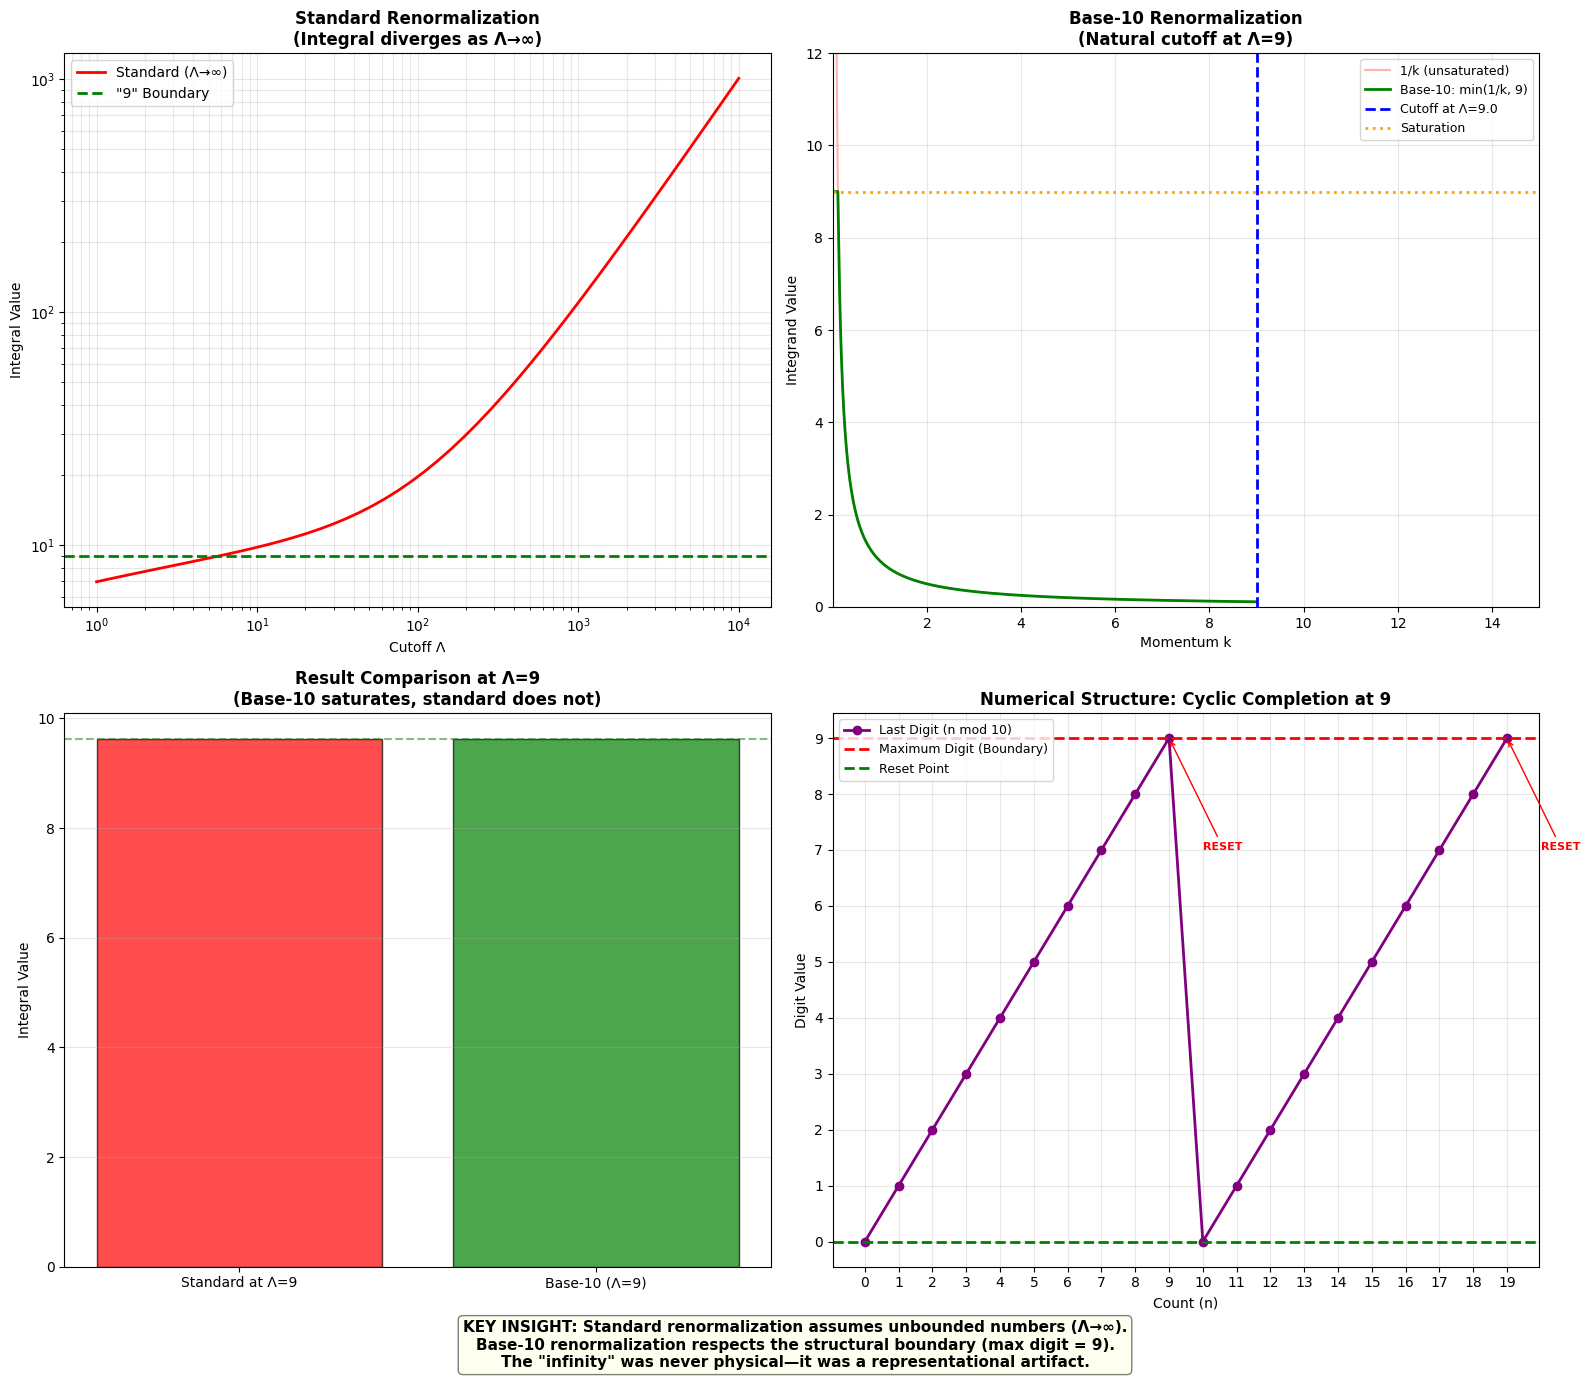

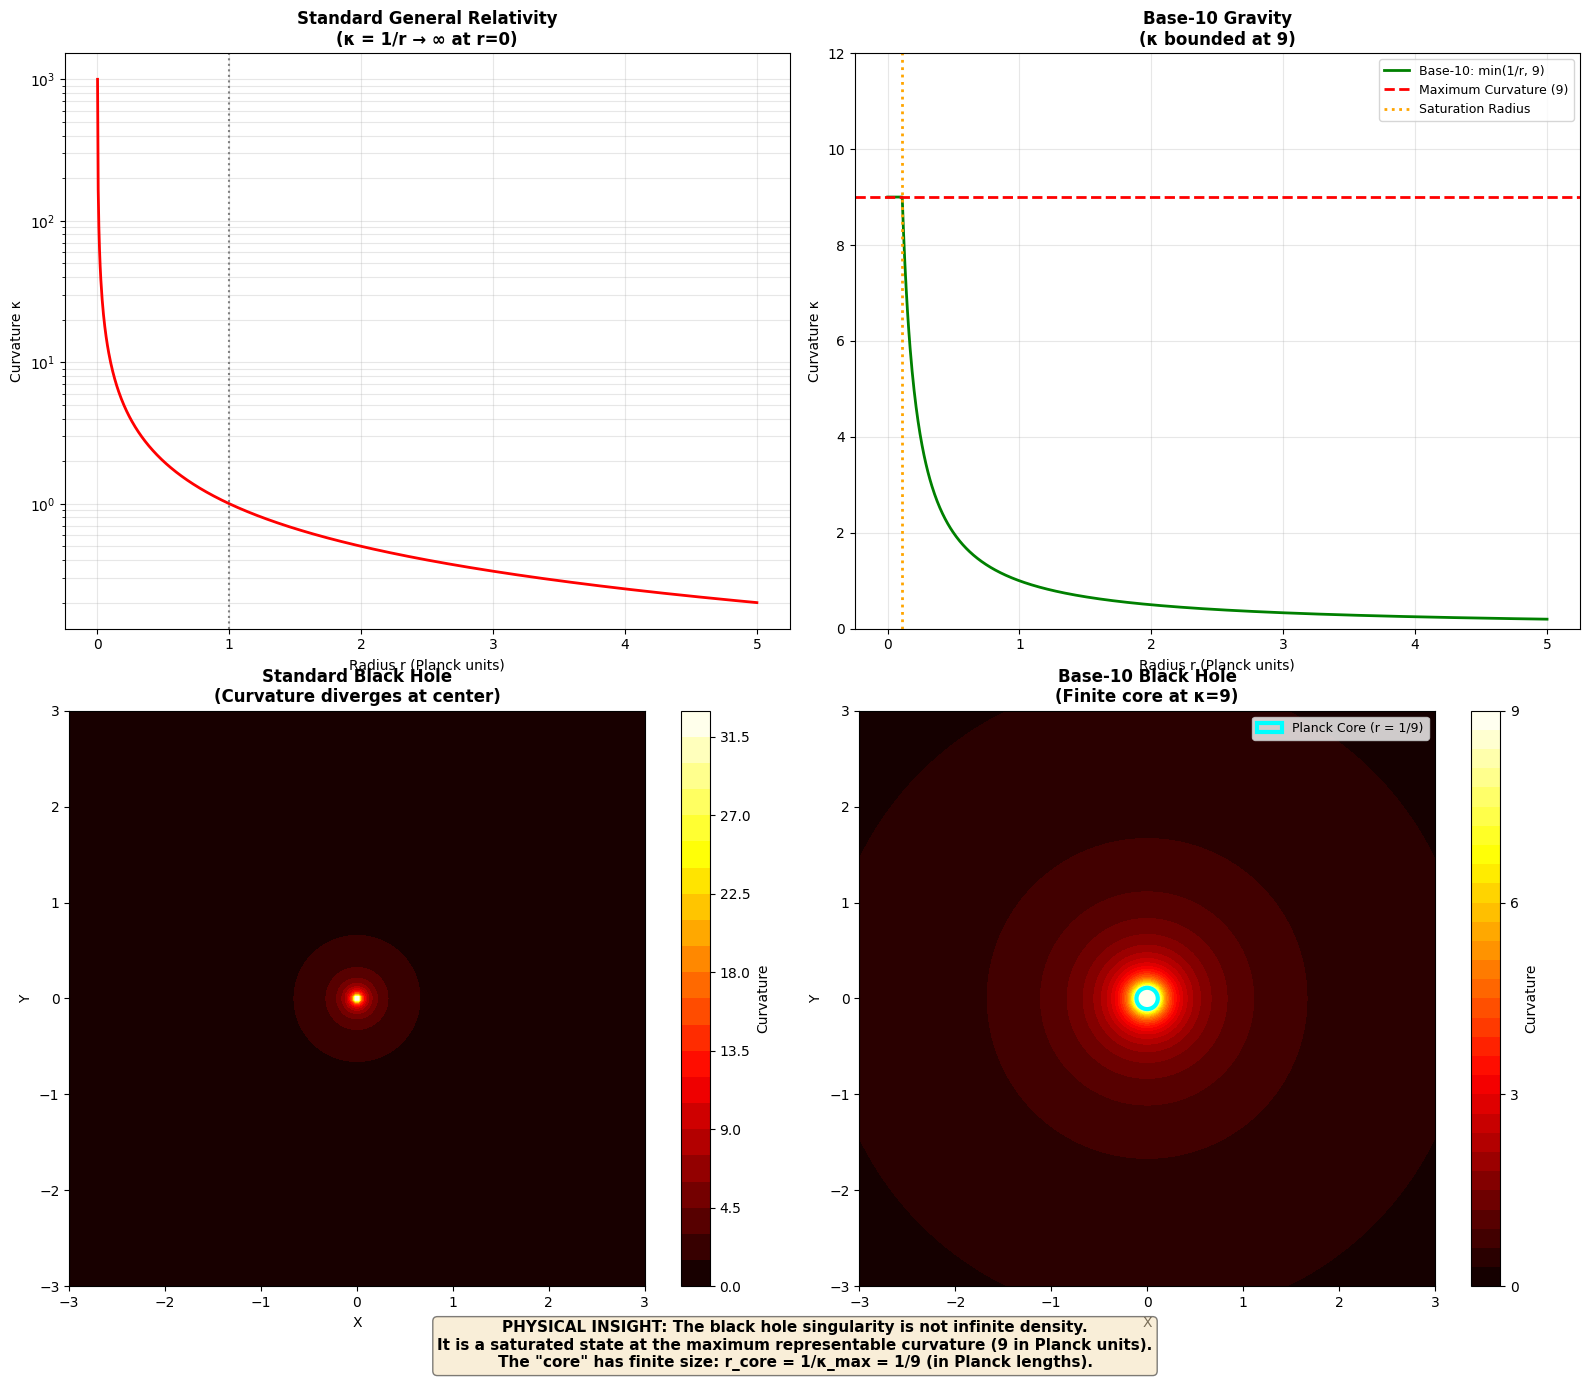

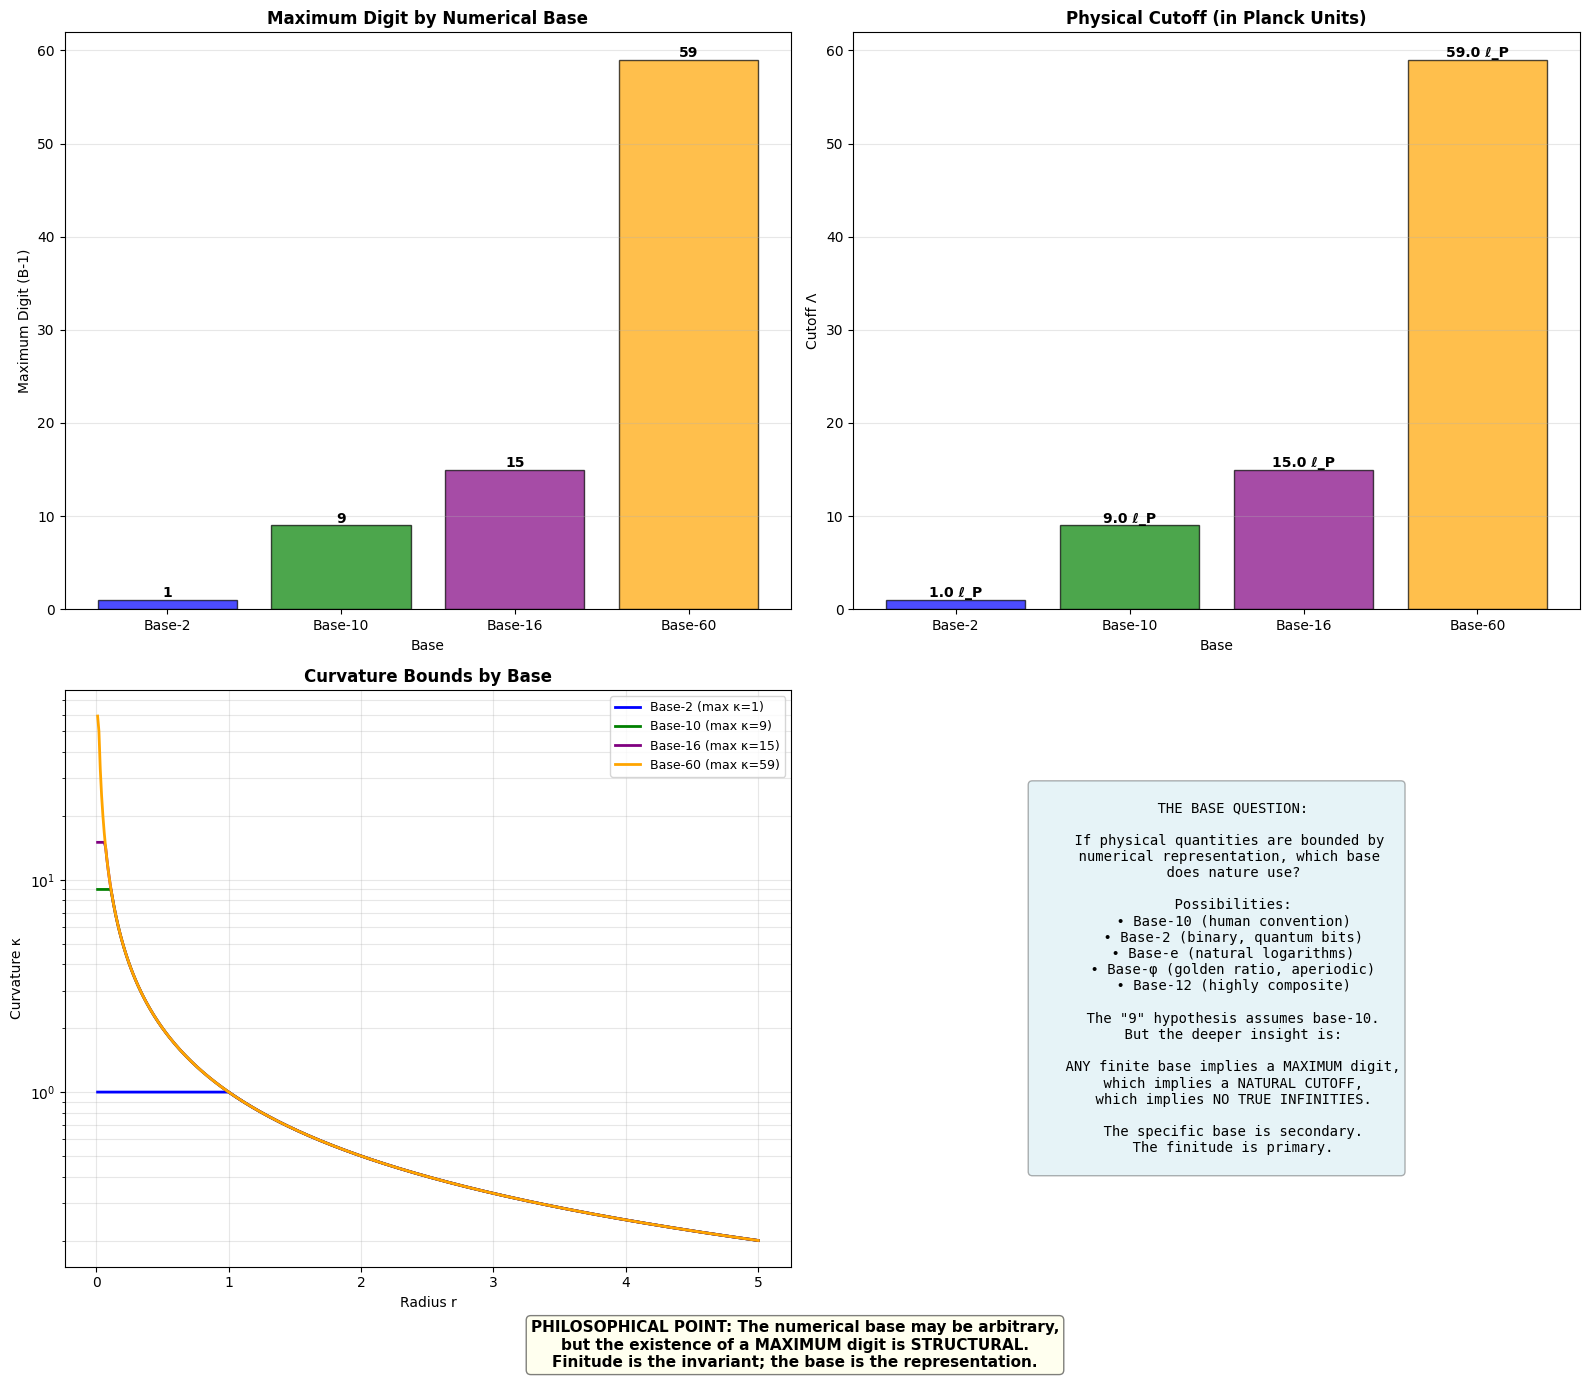

In [ ]:
"""
base10_renormalization.py
==========================
Exploring renormalization with a "9" cutoff.

Hypothesis: Physical quantities are bounded by the maximum digit (9)
in the fundamental numerical representation of reality.

Author: Néstor E. Ramos
For: "The Physical Singularity: Base-10 Renormalization"
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import viridis, ScalarMappable
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# PHYSICAL CONSTANTS (for visualization)
# =============================================================================

# Planck units (normalized to 1 for visualization)
PLANCK_LENGTH = 1.0
PLANCK_ENERGY = 1.0
PLANCK_CURVATURE = 1.0

# The "9" cutoff (in Planck units)
BASE = 10
MAX_DIGIT = BASE - 1  # 9 for base-10
CUTOFF = MAX_DIGIT * PLANCK_LENGTH  # Natural cutoff

# =============================================================================
# RENORMALIZATION SIMULATORS
# =============================================================================

def standard_renormalization(k_max_values, integrand_func):
    """
    Standard renormalization: take cutoff to infinity.

    Parameters:
    -----------
    k_max_values : array
        Sequence of cutoff values (Λ) to test
    integrand_func : callable
        Function f(k) to integrate

    Returns:
    --------
    results : list
        Integral values for each cutoff
    """
    results = []
    for k_max in k_max_values:
        # Numerical integration (simple Riemann sum)
        k = np.linspace(0.001, k_max, 10000)
        dk = k[1] - k[0]
        integral = np.sum(integrand_func(k) * dk)
        results.append(integral)
    return np.array(results)


def base10_renormalization(integrand_func, base=10):
    """
    Base-10 renormalization: cutoff at maximum digit (9).

    Parameters:
    -----------
    integrand_func : callable
        Function f(k) to integrate
    base : int
        Numerical base (10 for decimal)

    Returns:
    --------
    result : float
        Integral with natural cutoff at (base-1)
    max_digit : int
        The maximum digit (boundary)
    """
    max_digit = base - 1
    k_max = max_digit * PLANCK_LENGTH

    # Numerical integration up to natural cutoff
    k = np.linspace(0.001, k_max, 10000)
    dk = k[1] - k[0]
    integral = np.sum(integrand_func(k) * dk)

    return integral, max_digit


def saturating_integrand(k, saturation_value=9.0):
    """
    Example integrand that saturates at maximum digit.

    Models a physical quantity that cannot exceed the "9" boundary.
    """
    # Standard divergent behavior: 1/k
    raw_value = 1.0 / k

    # Saturate at maximum digit
    return np.minimum(raw_value, saturation_value)


def black_hole_curvature(r, max_curvature=9.0):
    """
    Black hole curvature with "9" saturation.

    Standard: κ = 1/r (diverges at r=0)
    Base-10: κ = min(1/r, 9) (bounded)
    """
    standard = 1.0 / np.maximum(r, 1e-10)  # Avoid division by zero
    return np.minimum(standard, max_curvature)


def electron_self_energy(momentum, max_energy=9.0):
    """
    Electron self-energy with "9" saturation.

    Standard: divergent integral
    Base-10: bounded by maximum representable energy
    """
    # Simplified model: energy ~ 1/p
    standard = 1.0 / np.maximum(momentum, 1e-10)
    return np.minimum(standard, max_energy)


# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def plot_standard_vs_base10_renormalization():
    """
    Compare standard renormalization (Λ→∞) vs. base-10 renormalization (Λ=9).
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    # Test integrand: 1/k (divergent)
    def integrand(k):
        return 1.0 / k

    # ===== TOP LEFT: Standard renormalization (divergence) =====
    ax1 = axes[0, 0]

    k_max_values = np.logspace(0, 4, 50)  # Λ from 1 to 10,000
    standard_results = standard_renormalization(k_max_values, integrand)

    ax1.loglog(k_max_values, standard_results, 'r-', linewidth=2, label='Standard (Λ→∞)')
    ax1.axhline(y=9.0, color='green', linestyle='--', linewidth=2, label='"9" Boundary')

    ax1.set_title('Standard Renormalization\n(Integral diverges as Λ→∞)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Cutoff Λ')
    ax1.set_ylabel('Integral Value')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3, which='both')

    # ===== TOP RIGHT: Base-10 renormalization (bounded) =====
    ax2 = axes[0, 1]

    base10_result, max_digit = base10_renormalization(integrand, base=10)

    # Show the integration range
    k = np.linspace(0.001, CUTOFF, 1000)
    y = integrand(k)
    y_saturated = np.minimum(y, max_digit)

    ax2.plot(k, y, 'r-', alpha=0.3, label='1/k (unsaturated)')
    ax2.plot(k, y_saturated, 'g-', linewidth=2, label=f'Base-10: min(1/k, {max_digit})')
    ax2.axvline(x=CUTOFF, color='blue', linestyle='--', linewidth=2, label=f'Cutoff at Λ={CUTOFF}')
    ax2.axhline(y=max_digit, color='orange', linestyle=':', linewidth=2, label='Saturation')

    ax2.set_title(f'Base-10 Renormalization\n(Natural cutoff at Λ={max_digit})', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Momentum k')
    ax2.set_ylabel('Integrand Value')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([0.001, 15])
    ax2.set_ylim([0, 12])

    # ===== BOTTOM LEFT: Convergence comparison =====
    ax3 = axes[1, 0]

    # Show how base-10 result compares to standard at various Λ
    standard_at_9 = standard_renormalization(np.array([9.0]), integrand)[0]

    ax3.bar(['Standard at Λ=9', 'Base-10 (Λ=9)'],
            [standard_at_9, base10_result],
            color=['red', 'green'], alpha=0.7, edgecolor='black')

    ax3.axhline(y=base10_result, color='green', linestyle='--', alpha=0.5)
    ax3.set_title('Result Comparison at Λ=9\n(Base-10 saturates, standard does not)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Integral Value')
    ax3.grid(True, alpha=0.3, axis='y')

    # ===== BOTTOM RIGHT: Physical interpretation =====
    ax4 = axes[1, 1]

    # Show the "digit cycle" concept
    n = np.arange(0, 20)
    digit = n % 10
    carry = n // 10

    ax4.plot(n, digit, 'o-', linewidth=2, markersize=6, color='purple', label='Last Digit (n mod 10)')
    ax4.axhline(y=9, color='red', linestyle='--', linewidth=2, label='Maximum Digit (Boundary)')
    ax4.axhline(y=0, color='green', linestyle='--', linewidth=2, label='Reset Point')

    # Annotate reset points
    for reset_point in [9, 19]:
        ax4.annotate('RESET', xy=(reset_point, 9), xytext=(reset_point+1, 7),
                    fontsize=8, fontweight='bold', color='red',
                    arrowprops=dict(arrowstyle='->', color='red'))

    ax4.set_title('Numerical Structure: Cyclic Completion at 9', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Count (n)')
    ax4.set_ylabel('Digit Value')
    ax4.set_xticks(n)
    ax4.set_yticks(np.arange(10))
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)

    # Add overarching text
    fig.text(0.5, 0.02,
             'KEY INSIGHT: Standard renormalization assumes unbounded numbers (Λ→∞).\n'
             'Base-10 renormalization respects the structural boundary (max digit = 9).\n'
             'The "infinity" was never physical—it was a representational artifact.',
             ha='center', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    return fig


def plot_black_hole_with_base10_cutoff():
    """
    Show how the "9" cutoff resolves the black hole singularity.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    # Radial coordinate (from center outward)
    r = np.linspace(0.001, 5, 1000)

    # ===== TOP LEFT: Standard curvature (divergent) =====
    ax1 = axes[0, 0]

    curvature_standard = 1.0 / r

    ax1.plot(r, curvature_standard, 'r-', linewidth=2)
    ax1.set_yscale('log')
    ax1.set_title('Standard General Relativity\n(κ = 1/r → ∞ at r=0)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Radius r (Planck units)')
    ax1.set_ylabel('Curvature κ')
    ax1.grid(True, alpha=0.3, which='both')
    ax1.axvline(x=PLANCK_LENGTH, color='gray', linestyle=':', label='Planck Scale')

    # ===== TOP RIGHT: Base-10 curvature (bounded) =====
    ax2 = axes[0, 1]

    curvature_base10 = black_hole_curvature(r, max_curvature=9.0)

    ax2.plot(r, curvature_base10, 'g-', linewidth=2, label='Base-10: min(1/r, 9)')
    ax2.axhline(y=9.0, color='red', linestyle='--', linewidth=2, label='Maximum Curvature (9)')
    ax2.axvline(x=1/9, color='orange', linestyle=':', linewidth=2, label='Saturation Radius')

    ax2.set_title(f'Base-10 Gravity\n(κ bounded at {MAX_DIGIT})', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Radius r (Planck units)')
    ax2.set_ylabel('Curvature κ')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 12])

    # ===== BOTTOM LEFT: 2D cross-section =====
    ax3 = axes[1, 0]

    # Create a 2D grid
    x = np.linspace(-3, 3, 200)
    y = np.linspace(-3, 3, 200)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)

    # Standard curvature (clipped for visualization)
    Z_standard = np.minimum(1.0 / (R + 0.01), 50)

    contour = ax3.contourf(X, Y, Z_standard, levels=30, cmap='hot')
    ax3.set_title('Standard Black Hole\n(Curvature diverges at center)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('X'); ax3.set_ylabel('Y')
    ax3.set_aspect('equal')
    plt.colorbar(contour, ax=ax3, label='Curvature')

    # ===== BOTTOM RIGHT: Base-10 2D cross-section =====
    ax4 = axes[1, 1]

    # Base-10 curvature (bounded)
    Z_base10 = black_hole_curvature(R, max_curvature=9.0)

    contour = ax4.contourf(X, Y, Z_base10, levels=30, cmap='hot', vmin=0, vmax=9)

    # Draw the "Planck core" boundary
    core_radius = 1/9
    circle = plt.Circle((0, 0), core_radius, color='cyan', fill=False,
                        linewidth=3, label='Planck Core (r = 1/9)')
    ax4.add_patch(circle)

    ax4.set_title(f'Base-10 Black Hole\n(Finite core at κ={MAX_DIGIT})', fontsize=12, fontweight='bold')
    ax4.set_xlabel('X'); ax4.set_ylabel('Y')
    ax4.set_aspect('equal')
    ax4.legend(fontsize=9)
    plt.colorbar(contour, ax=ax4, label='Curvature', ticks=[0, 3, 6, 9])

    # Add overarching text
    fig.text(0.5, 0.02,
             'PHYSICAL INSIGHT: The black hole singularity is not infinite density.\n'
             'It is a saturated state at the maximum representable curvature (9 in Planck units).\n'
             'The "core" has finite size: r_core = 1/κ_max = 1/9 (in Planck lengths).',
             ha='center', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    return fig


def plot_digit_based_cutoffs():
    """
    Show how different numerical bases imply different physical cutoffs.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    bases = [2, 10, 16, 60]  # Binary, Decimal, Hexadecimal, Sexagesimal
    colors = ['blue', 'green', 'purple', 'orange']

    # ===== TOP LEFT: Maximum digit vs. base =====
    ax1 = axes[0, 0]

    max_digits = [b-1 for b in bases]
    ax1.bar([f'Base-{b}' for b in bases], max_digits, color=colors, alpha=0.7, edgecolor='black')

    for i, (b, d) in enumerate(zip(bases, max_digits)):
        ax1.text(i, d + 0.3, f'{d}', ha='center', fontweight='bold')

    ax1.set_title('Maximum Digit by Numerical Base', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Base')
    ax1.set_ylabel('Maximum Digit (B-1)')
    ax1.grid(True, alpha=0.3, axis='y')

    # ===== TOP RIGHT: Corresponding physical cutoff =====
    ax2 = axes[0, 1]

    # Assume cutoff = (max_digit) × Planck_unit
    cutoffs = np.array(max_digits) * PLANCK_LENGTH

    ax2.bar([f'Base-{b}' for b in bases], cutoffs, color=colors, alpha=0.7, edgecolor='black')

    for i, (b, c) in enumerate(zip(bases, cutoffs)):
        ax2.text(i, c + 0.3, f'{c:.1f} ℓ_P', ha='center', fontweight='bold')

    ax2.set_title('Physical Cutoff (in Planck Units)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Base')
    ax2.set_ylabel('Cutoff Λ')
    ax2.grid(True, alpha=0.3, axis='y')

    # ===== BOTTOM LEFT: Curvature bound comparison =====
    ax3 = axes[1, 0]

    r = np.linspace(0.01, 5, 500)

    for b, color in zip(bases, colors):
        max_curv = b - 1
        curvature = np.minimum(1.0 / r, max_curv)
        ax3.plot(r, curvature, color=color, linewidth=2, label=f'Base-{b} (max κ={max_curv})')

    ax3.set_title('Curvature Bounds by Base', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Radius r')
    ax3.set_ylabel('Curvature κ')
    ax3.set_yscale('log')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3, which='both')

    # ===== BOTTOM RIGHT: Philosophical implication =====
    ax4 = axes[1, 1]
    ax4.axis('off')

    text = """
    THE BASE QUESTION:

    If physical quantities are bounded by
    numerical representation, which base
    does nature use?

    Possibilities:
    • Base-10 (human convention)
    • Base-2 (binary, quantum bits)
    • Base-e (natural logarithms)
    • Base-φ (golden ratio, aperiodic)
    • Base-12 (highly composite)

    The "9" hypothesis assumes base-10.
    But the deeper insight is:

    ANY finite base implies a MAXIMUM digit,
    which implies a NATURAL CUTOFF,
    which implies NO TRUE INFINITIES.

    The specific base is secondary.
    The finitude is primary.
    """

    ax4.text(0.5, 0.5, text, ha='center', va='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3),
             family='monospace')

    # Add overarching text
    fig.text(0.5, 0.02,
             'PHILOSOPHICAL POINT: The numerical base may be arbitrary,\n'
             'but the existence of a MAXIMUM digit is STRUCTURAL.\n'
             'Finitude is the invariant; the base is the representation.',
             ha='center', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    return fig


# =============================================================================
# MAIN EXECUTION
# =============================================================================

def main():
    """Generate all base-10 renormalization visualizations."""

    print("\n" + "=" * 70)
    print("BASE-10 RENORMALIZATION VISUALIZATION SUITE")
    print("=" * 70)
    print(f"\nHypothesis: Physical quantities are bounded by the maximum")
    print(f"digit in the fundamental numerical representation of reality.")
    print(f"For base-10: maximum digit = 9 → natural cutoff at Λ = 9")
    print("=" * 70)

    print("\n[1/3] Standard vs. Base-10 Renormalization...")
    fig1 = plot_standard_vs_base10_renormalization()
    fig1.savefig("base10_renormalization_comparison.png", dpi=300, bbox_inches='tight')
    print("  ✓ Saved: base10_renormalization_comparison.png")

    print("\n[2/3] Black Hole with Base-10 Cutoff...")
    fig2 = plot_black_hole_with_base10_cutoff()
    fig2.savefig("black_hole_base10_core.png", dpi=300, bbox_inches='tight')
    print("  ✓ Saved: black_hole_base10_core.png")

    print("\n[3/3] Numerical Base Dependence...")
    fig3 = plot_digit_based_cutoffs()
    fig3.savefig("base_dependence_cutoffs.png", dpi=300, bbox_inches='tight')
    print("  ✓ Saved: base_dependence_cutoffs.png")

    print("\n" + "=" * 70)
    print("VISUALIZATIONS COMPLETE!")
    print("=" * 70)
    print("\n📁 FILES GENERATED:")
    print("  • base10_renormalization_comparison.png")
    print("  • black_hole_base10_core.png")
    print("  • base_dependence_cutoffs.png")
    print("\n KEY INSIGHTS:")
    print("  1. Standard renormalization: Λ→∞ (arbitrary, divergent)")
    print("  2. Base-10 renormalization: Λ=9 (structural, bounded)")
    print("  3. Black hole singularity: not infinite density, but saturated state")
    print("  4. The specific base may vary, but FINITUDE is invariant")
    print("\n" + "=" * 70)
    print("Foundation for Paper #2: 'Base-10 Renormalization'")
    print("=" * 70)

    plt.show()


if __name__ == "__main__":
    main()